# Singing Voice Synthesis — Exploratory Data Analysis

Analysis of the synthesized singing voice dataset generated from DALI v2.0 annotations via the v2 iterative alignment pipeline.

In [1]:
import os, json, gzip, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = Path("../Data/Rachie")
DALI_ANNOT_DIR = Path("../DALI/DALI_v2.0/annot_tismir")

manifest = pd.read_csv(DATA_DIR / "manifest.csv")
print(f"Manifest: {len(manifest):,} chunks across {manifest['dali_id'].nunique()} songs")
manifest.head()

Manifest: 160,467 chunks across 2890 songs


,provider,prompt_name,dali_id,chunk_name,prior_mel_path,target_mel_path,f0_path,voicing_path,phoneme_mask_path,adjusted_notes_path,converged,iterations,dtw_cost,mean_deviation,max_deviation
0,Rachie,rachie_high,00070c7c333849e4a3725b906c339042,line_0,00070c7c333849e4a3725b906c339042/line_0/prior_...,00070c7c333849e4a3725b906c339042/line_0/target...,00070c7c333849e4a3725b906c339042/line_0/target...,00070c7c333849e4a3725b906c339042/line_0/target...,00070c7c333849e4a3725b906c339042/line_0/phonem...,00070c7c333849e4a3725b906c339042/line_0/adjust...,True,2,34.4047,0.0551,0.0769
1,Rachie,rachie_high,00070c7c333849e4a3725b906c339042,line_1,00070c7c333849e4a3725b906c339042/line_1/prior_...,00070c7c333849e4a3725b906c339042/line_1/target...,00070c7c333849e4a3725b906c339042/line_1/target...,00070c7c333849e4a3725b906c339042/line_1/target...,00070c7c333849e4a3725b906c339042/line_1/phonem...,00070c7c333849e4a3725b906c339042/line_1/adjust...,False,3,56.8656,NaN,0.3636
2,Rachie,rachie_high,00070c7c333849e4a3725b906c339042,line_10,00070c7c333849e4a3725b906c339042/line_10/prior...,00070c7c333849e4a3725b906c339042/line_10/targe...,00070c7c333849e4a3725b906c339042/line_10/targe...,00070c7c333849e4a3725b906c339042/line_10/targe...,00070c7c333849e4a3725b906c339042/line_10/phone...,00070c7c333849e4a3725b906c339042/line_10/adjus...,False,3,56.7252,NaN,0.4815
3,Rachie,rachie_high,00070c7c333849e4a3725b906c339042,line_11,00070c7c333849e4a3725b906c339042/line_11/prior...,00070c7c333849e4a3725b906c339042/line_11/targe...,00070c7c333849e4a3725b906c339042/line_11/targe...,00070c7c333849e4a3725b906c339042/line_11/targe...,00070c7c333849e4a3725b906c339042/line_11/phone...,00070c7c333849e4a3725b906c339042/line_11/adjus...,False,3,98.5560,NaN,0.1538
4,Rachie,rachie_mid,00070c7c333849e4a3725b906c339042,line_12,00070c7c333849e4a3725b906c339042/line_12/prior...,00070c7c333849e4a3725b906c339042/line_12/targe...,00070c7c333849e4a3725b906c339042/line_12/targe...,00070c7c333849e4a3725b906c339042/line_12/targe...,00070c7c333849e4a3725b906c339042/line_12/phone...,00070c7c333849e4a3725b906c339042/line_12/adjus...,False,3,74.8070,NaN,0.4000


## 1. Data Completeness

How much of the English DALI dataset have we processed?

In [2]:
# Count total English songs in DALI v2.0
english_ids = []
for fname in tqdm(sorted(os.listdir(DALI_ANNOT_DIR)), desc="Scanning DALI"):
    if not fname.endswith(".gz"):
        continue
    try:
        with gzip.open(DALI_ANNOT_DIR / fname, "rb") as fh:
            obj = pickle.load(fh)
        lang = obj.info.get("metadata", {}).get("language", "")
        if lang.lower() == "english":
            english_ids.append(fname.replace(".gz", ""))
    except Exception:
        pass


Scanning DALI:   0%|          | 0/7756 [00:00<?, ?it/s]

In [3]:
processed_ids = set(manifest["dali_id"].unique())
total_english = len(english_ids)
processed_count = len(processed_ids)
missing_ids = set(english_ids) - processed_ids

print(f"Total English DALI songs: {total_english:,}")
print(f"Songs in dataset:         {processed_count:,} ({100*processed_count/total_english:.1f}%)")
print(f"Missing songs:            {len(missing_ids):,}")

Total English DALI songs: 5,913
Songs in dataset:         2,890 (48.9%)
Missing songs:            3,024


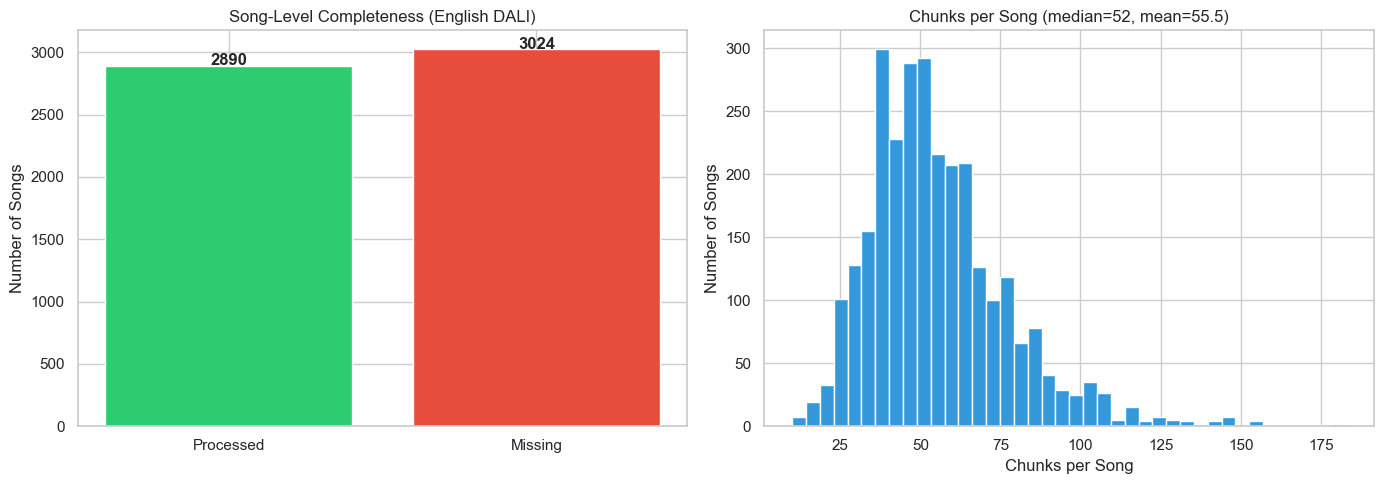

In [4]:
# Bar chart: processed vs total English DALI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: song-level completeness
axes[0].bar(["Processed", "Missing"], [processed_count, len(missing_ids)],
            color=["#2ecc71", "#e74c3c"])
axes[0].set_ylabel("Number of Songs")
axes[0].set_title("Song-Level Completeness (English DALI)")
for i, v in enumerate([processed_count, len(missing_ids)]):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Right: chunks per song
chunks_per_song = manifest.groupby("dali_id").size()
axes[1].hist(chunks_per_song, bins=40, color="#3498db", edgecolor="white")
axes[1].set_xlabel("Chunks per Song")
axes[1].set_ylabel("Number of Songs")
axes[1].set_title(f"Chunks per Song (median={chunks_per_song.median():.0f}, mean={chunks_per_song.mean():.1f})")

plt.tight_layout()
plt.show()

## 2. Alignment Quality

How well did the iterative alignment converge? Distribution of DTW costs and deviations.

Convergence breakdown:
  Converged:     41,811  (26.1%)
  Not converged: 118,656  (73.9%)


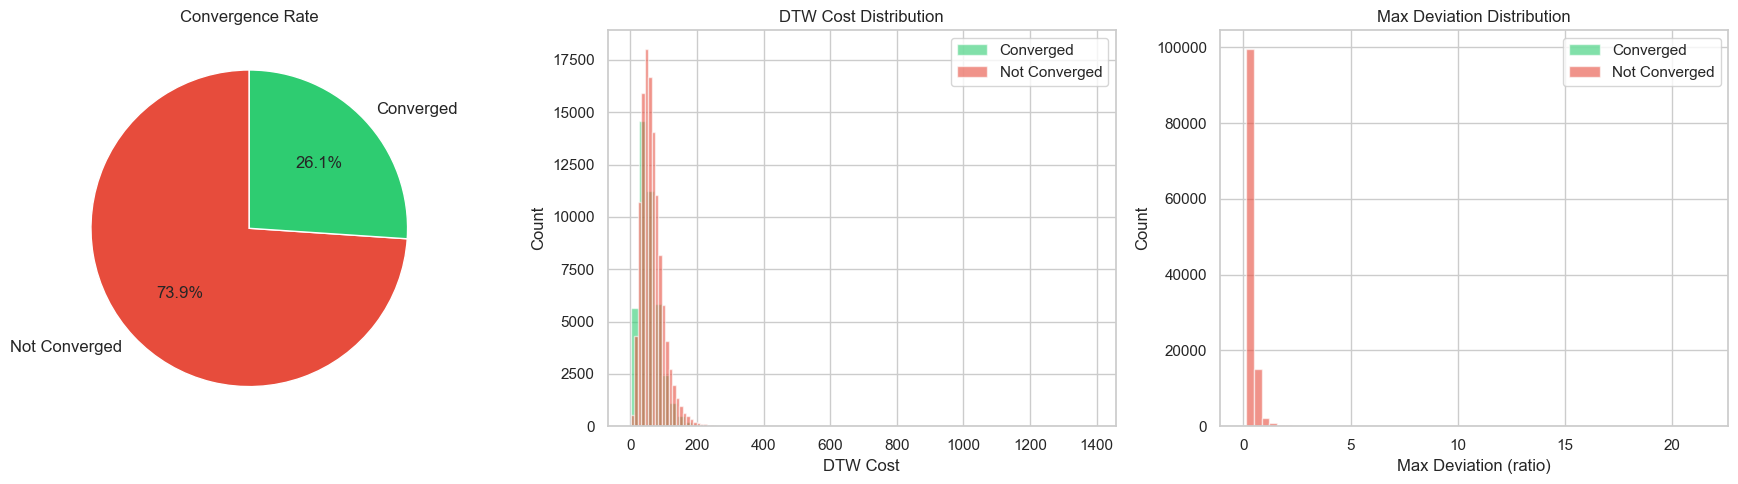

In [5]:
# Convergence rate
conv_counts = manifest["converged"].value_counts()
print("Convergence breakdown:")
print(f"  Converged:     {conv_counts.get(True, 0):>6,}  ({100*conv_counts.get(True,0)/len(manifest):.1f}%)")
print(f"  Not converged: {conv_counts.get(False, 0):>6,}  ({100*conv_counts.get(False,0)/len(manifest):.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart: convergence
axes[0].pie(conv_counts.values, labels=["Not Converged", "Converged"],
            colors=["#e74c3c", "#2ecc71"], autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 12})
axes[0].set_title("Convergence Rate")

# DTW cost histogram by convergence
for conv, color, label in [(True, "#2ecc71", "Converged"), (False, "#e74c3c", "Not Converged")]:
    subset = manifest[manifest["converged"] == conv]["dtw_cost"].dropna()
    axes[1].hist(subset, bins=60, alpha=0.6, color=color, label=label, edgecolor="white")
axes[1].set_xlabel("DTW Cost")
axes[1].set_ylabel("Count")
axes[1].set_title("DTW Cost Distribution")
axes[1].legend()

# Max deviation histogram by convergence
for conv, color, label in [(True, "#2ecc71", "Converged"), (False, "#e74c3c", "Not Converged")]:
    subset = manifest[manifest["converged"] == conv]["max_deviation"].dropna()
    axes[2].hist(subset, bins=60, alpha=0.6, color=color, label=label, edgecolor="white")
axes[2].set_xlabel("Max Deviation (ratio)")
axes[2].set_ylabel("Count")
axes[2].set_title("Max Deviation Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

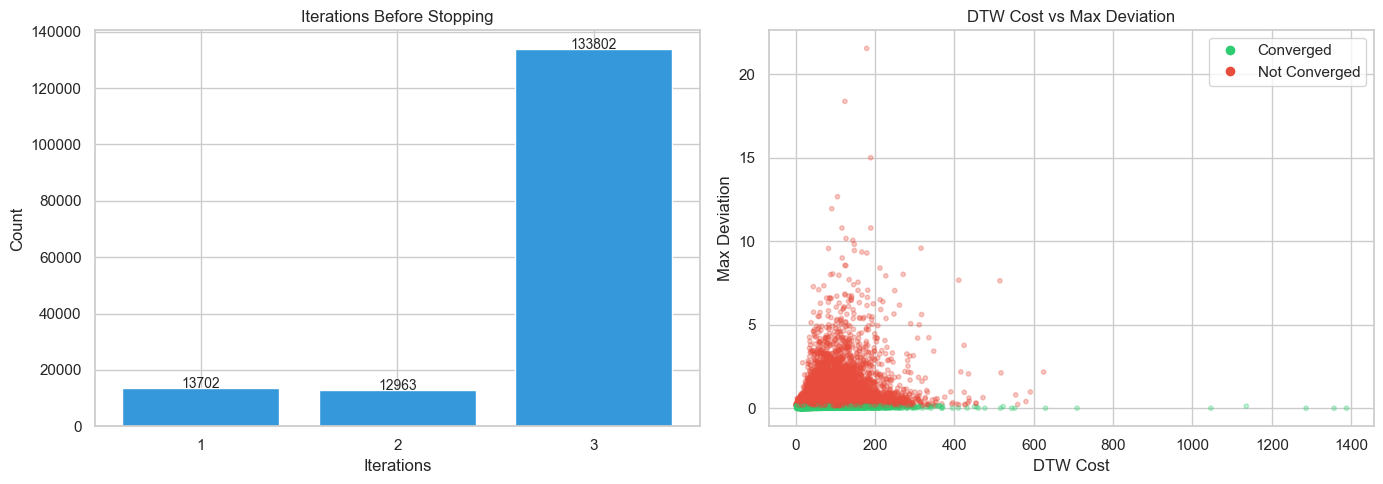

In [6]:
# Iterations distribution & DTW cost vs max deviation scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iterations bar chart
iter_counts = manifest["iterations"].value_counts().sort_index()
axes[0].bar(iter_counts.index.astype(str), iter_counts.values, color="#3498db", edgecolor="white")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Count")
axes[0].set_title("Iterations Before Stopping")
for i, (idx, v) in enumerate(iter_counts.items()):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=10)

# DTW cost vs max deviation scatter
valid = manifest.dropna(subset=["dtw_cost", "max_deviation"])
colors = valid["converged"].map({True: "#2ecc71", False: "#e74c3c"})
axes[1].scatter(valid["dtw_cost"], valid["max_deviation"], c=colors, alpha=0.3, s=10)
axes[1].set_xlabel("DTW Cost")
axes[1].set_ylabel("Max Deviation")
axes[1].set_title("DTW Cost vs Max Deviation")
# Manual legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=8, label='Converged'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Not Converged')]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 3. Chunk Length Analysis

Distribution of chunk durations (seconds) and word counts.

In [7]:
# Load per-chunk metadata: duration from music.json, word count from chunk_words.json
durations = []
word_counts = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Loading chunk metadata"):
    chunk_dir = DATA_DIR / row["dali_id"] / row["chunk_name"]

    # Duration from music.json
    music_path = chunk_dir / "music.json"
    if music_path.exists():
        with open(music_path) as f:
            music = json.load(f)
        # time field is [start_ms, end_ms]
        t = music[0].get("time", [0, 0])
        dur_s = (t[1] - t[0]) / 1000.0
        durations.append(dur_s)
    else:
        durations.append(np.nan)

    # Word count from chunk_words.json
    words_path = chunk_dir / "chunk_words.json"
    if words_path.exists():
        with open(words_path) as f:
            words = json.load(f)
        word_counts.append(len(words))
    else:
        word_counts.append(np.nan)

manifest["duration_s"] = durations
manifest["word_count"] = word_counts
print(f"Duration: median={np.nanmedian(durations):.2f}s, mean={np.nanmean(durations):.2f}s")
print(f"Words:    median={np.nanmedian(word_counts):.0f}, mean={np.nanmean(word_counts):.1f}")

Loading chunk metadata:   0%|          | 0/160467 [00:00<?, ?it/s]

Duration: median=2.18s, mean=2.47s
Words:    median=5, mean=4.7


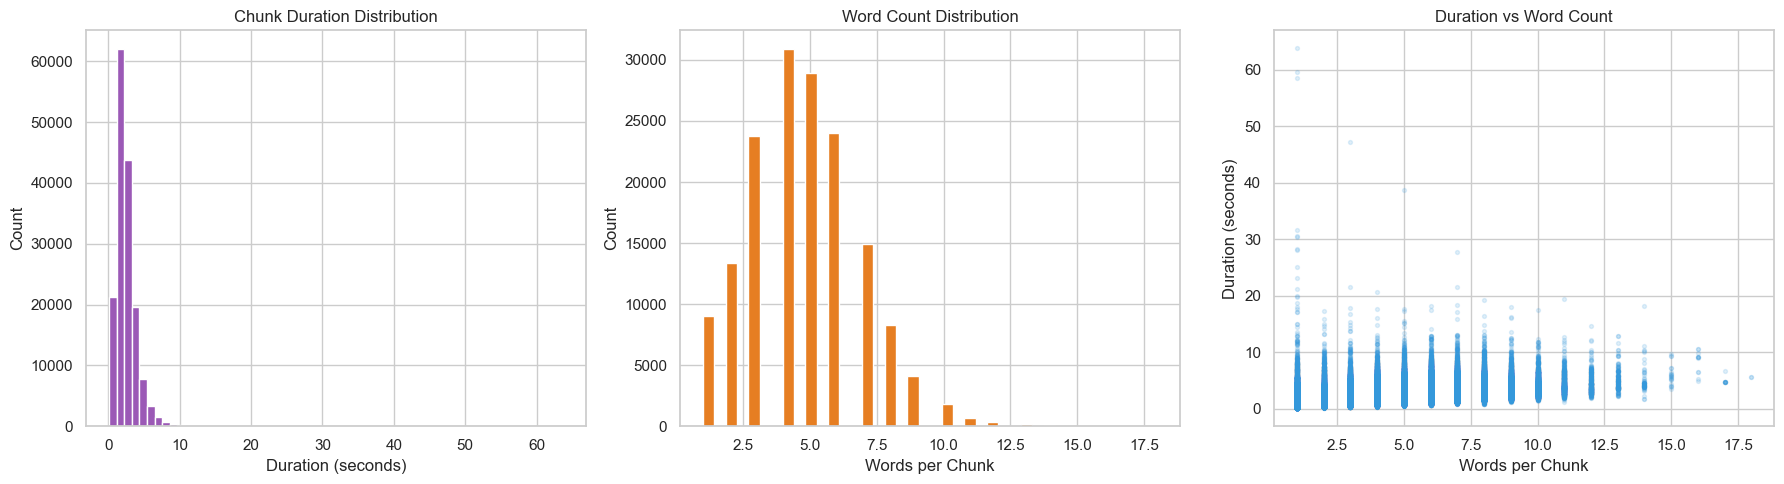

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Duration histogram
axes[0].hist(manifest["duration_s"].dropna(), bins=60, color="#9b59b6", edgecolor="white")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Count")
axes[0].set_title("Chunk Duration Distribution")

# Word count histogram
axes[1].hist(manifest["word_count"].dropna(), bins=40, color="#e67e22", edgecolor="white")
axes[1].set_xlabel("Words per Chunk")
axes[1].set_ylabel("Count")
axes[1].set_title("Word Count Distribution")

# Duration vs word count scatter
valid_dw = manifest.dropna(subset=["duration_s", "word_count"])
axes[2].scatter(valid_dw["word_count"], valid_dw["duration_s"], alpha=0.15, s=8, color="#3498db")
axes[2].set_xlabel("Words per Chunk")
axes[2].set_ylabel("Duration (seconds)")
axes[2].set_title("Duration vs Word Count")

plt.tight_layout()
plt.show()

### DTW Threshold vs Available Data

How much usable data remains as we raise or lower the quality bar?

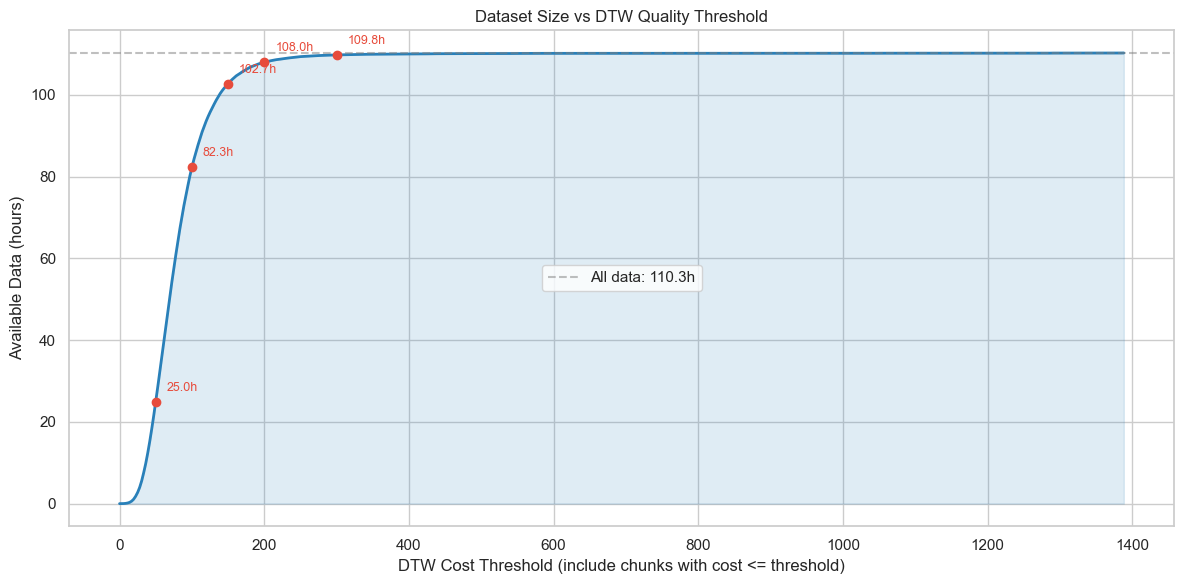

In [9]:
# DTW cost threshold vs available data hours
# For each threshold, include all chunks with dtw_cost <= threshold and sum their durations
thresholds = np.linspace(0, manifest["dtw_cost"].max(), 500)
hours_at_threshold = []
for t in thresholds:
    mask = manifest["dtw_cost"] <= t
    hours_at_threshold.append(manifest.loc[mask, "duration_s"].sum() / 3600)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, hours_at_threshold, color="#2980b9", linewidth=2)
ax.fill_between(thresholds, hours_at_threshold, alpha=0.15, color="#2980b9")

# Mark a few reference points
total_hrs = manifest["duration_s"].sum() / 3600
for ref_t in [50, 100, 150, 200, 300]:
    hrs = manifest.loc[manifest["dtw_cost"] <= ref_t, "duration_s"].sum() / 3600
    ax.plot(ref_t, hrs, "o", color="#e74c3c", markersize=6, zorder=5)
    ax.annotate(f"{hrs:.1f}h", (ref_t, hrs), textcoords="offset points",
                xytext=(8, 8), fontsize=9, color="#e74c3c")

ax.set_xlabel("DTW Cost Threshold (include chunks with cost <= threshold)")
ax.set_ylabel("Available Data (hours)")
ax.set_title("Dataset Size vs DTW Quality Threshold")
ax.axhline(total_hrs, color="gray", linestyle="--", alpha=0.5, label=f"All data: {total_hrs:.1f}h")
ax.legend()
plt.tight_layout()
plt.show()

### Sample Audio by DTW Quality Tier

Listen to representative prior/target pairs at different DTW cost thresholds. Each sample is chosen near the median DTW cost within its tier.

In [10]:
from IPython.display import display, Audio, HTML

dtw_thresholds = [50, 100, 150, 200]
sep = '=' * 60

for threshold in dtw_thresholds:
    tier = manifest[manifest['dtw_cost'] <= threshold].copy()
    if len(tier) == 0:
        print(sep)
        print(f'DTW <= {threshold}: No chunks in this range')
        continue

    # Pick the chunk closest to the median DTW cost in this tier
    median_cost = tier['dtw_cost'].median()
    best_idx = (tier['dtw_cost'] - median_cost).abs().idxmin()
    row = tier.loc[best_idx]

    chunk_dir = DATA_DIR / row['dali_id'] / row['chunk_name']

    # Load lyrics
    words_path = chunk_dir / 'chunk_words.json'
    lyrics = ''
    if words_path.exists():
        with open(words_path) as f:
            lyrics = ' '.join(json.load(f))

    cost_val = row['dtw_cost']
    conv_val = row['converged']
    dali_val = row['dali_id']
    chunk_val = row['chunk_name']
    display(HTML(f'<h4>DTW &le; {threshold} &mdash; median sample (cost={cost_val:.1f}, converged={conv_val})</h4>'))
    display(HTML(f'<b>Song:</b> <code>{dali_val}</code> / <code>{chunk_val}</code> &nbsp; <b>Lyrics:</b> {lyrics}'))

    target_wav = chunk_dir / 'target.wav'
    prior_wav = chunk_dir / 'prior.wav'

    if target_wav.exists():
        display(HTML('<b>Target</b> (SoulX-Singer synthesis):'))
        display(Audio(filename=str(target_wav)))
    if prior_wav.exists():
        display(HTML('<b>Prior</b> (OpenUtau, iteratively aligned):'))
        display(Audio(filename=str(prior_wav)))
    print()


## 4. Note-Level Analysis

Pitch distribution, voicing ratios, and note durations from `adjusted_notes.json`.

In [11]:
# Load note-level data from adjusted_notes.json
all_pitches = []
all_voicing_ratios = []
all_note_durations = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Loading notes"):
    notes_path = DATA_DIR / row["adjusted_notes_path"]
    if not notes_path.exists():
        continue
    with open(notes_path) as f:
        data = json.load(f)
    for note in data.get("notes", []):
        all_pitches.append(note.get("note_pitch", np.nan))
        all_voicing_ratios.append(note.get("voiced_ratio", np.nan))
        all_note_durations.append(note.get("note_dur", np.nan))

print(f"Total notes loaded: {len(all_pitches):,}")

Loading notes:   0%|          | 0/160467 [00:00<?, ?it/s]

KeyboardInterrupt: 

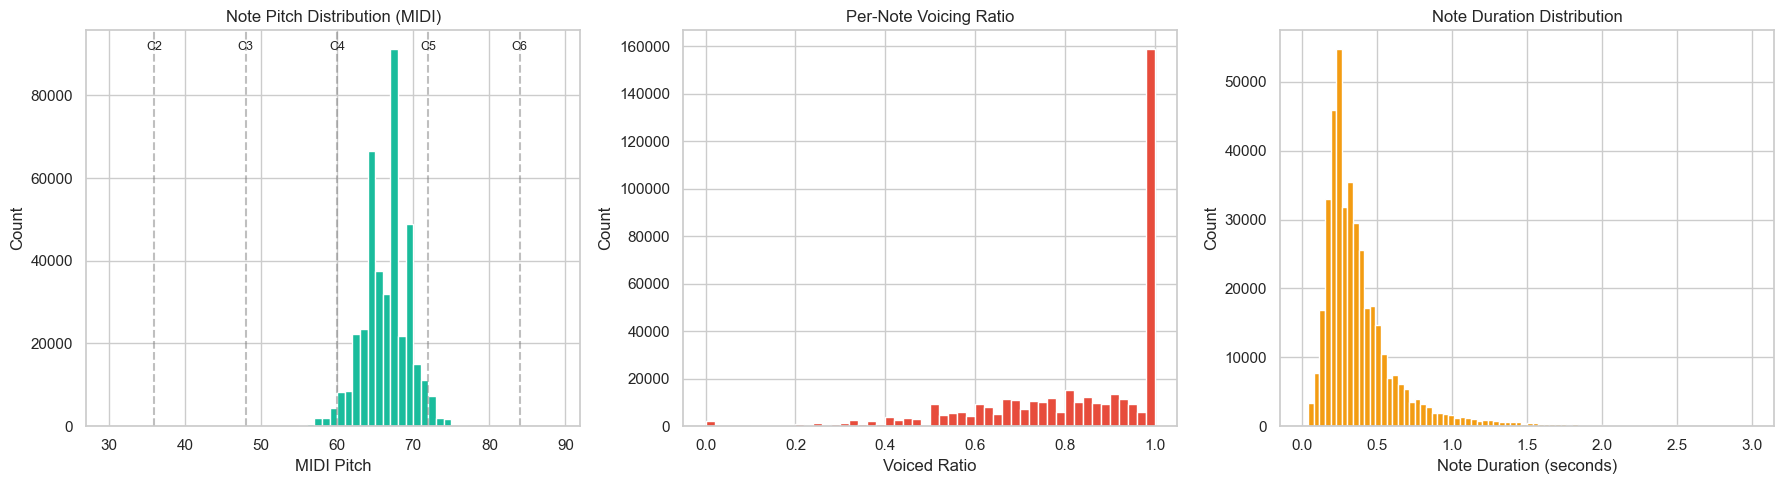

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MIDI pitch distribution
axes[0].hist(all_pitches, bins=range(30, 90), color="#1abc9c", edgecolor="white")
axes[0].set_xlabel("MIDI Pitch")
axes[0].set_ylabel("Count")
axes[0].set_title("Note Pitch Distribution (MIDI)")
# Add note name labels for reference
pitch_labels = {36: "C2", 48: "C3", 60: "C4", 72: "C5", 84: "C6"}
for midi, name in pitch_labels.items():
    if 30 <= midi < 90:
        axes[0].axvline(midi, color="gray", linestyle="--", alpha=0.5)
        axes[0].text(midi, axes[0].get_ylim()[1]*0.95, name, ha="center", fontsize=9)

# Voicing ratio distribution
axes[1].hist(all_voicing_ratios, bins=50, color="#e74c3c", edgecolor="white")
axes[1].set_xlabel("Voiced Ratio")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-Note Voicing Ratio")

# Note duration distribution
axes[2].hist(all_note_durations, bins=80, color="#f39c12", edgecolor="white", range=(0, 3))
axes[2].set_xlabel("Note Duration (seconds)")
axes[2].set_ylabel("Count")
axes[2].set_title("Note Duration Distribution")

plt.tight_layout()
plt.show()

### DALI Ground Truth Pitch Distribution

Compare the synthesized pitch distribution above with the original DALI note annotations (Hz converted to MIDI).

Loading DALI pitches:   0%|          | 0/1175 [00:00<?, ?it/s]

DALI ground truth notes: 408,328
Synthesized notes:       408,417


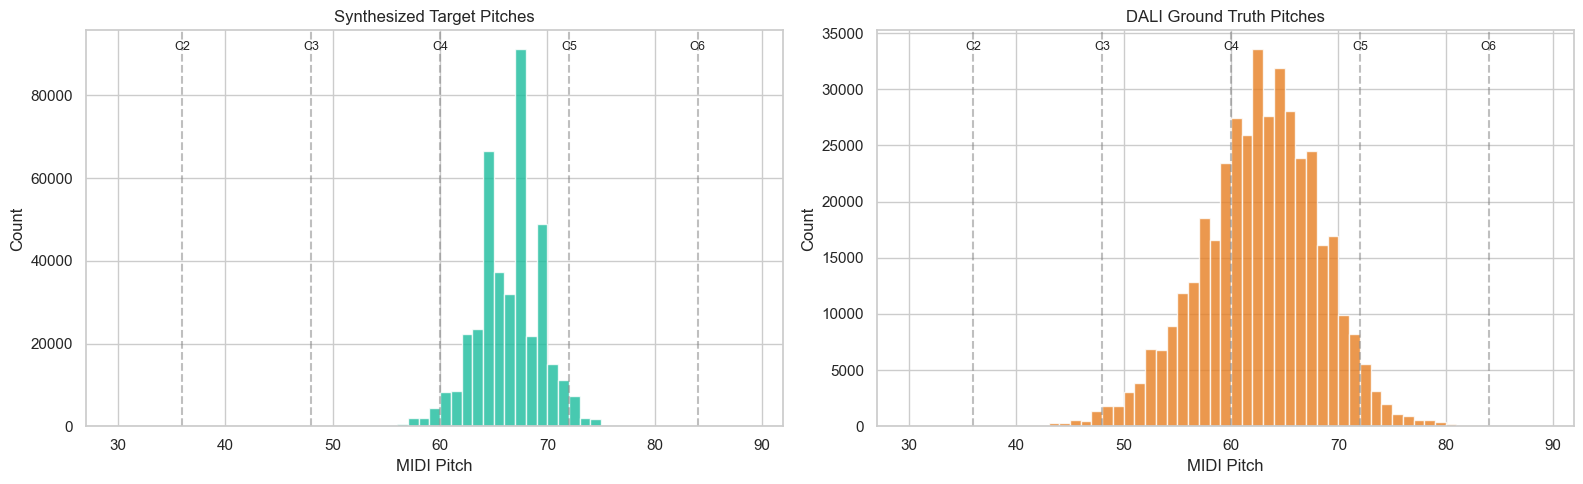

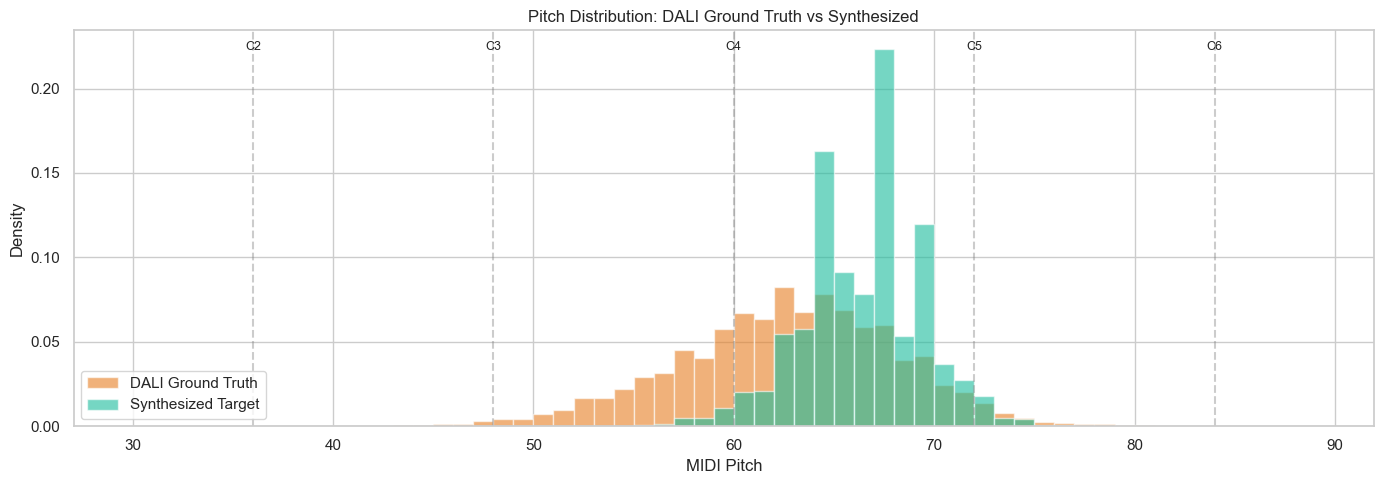

In [ ]:
# Extract MIDI pitches from DALI ground truth annotations for processed songs
dali_pitches = []

for dali_id in tqdm(manifest['dali_id'].unique(), desc='Loading DALI pitches'):
    gz_path = DALI_ANNOT_DIR / f'{dali_id}.gz'
    if not gz_path.exists():
        continue
    try:
        with gzip.open(gz_path, 'rb') as fh:
            obj = pickle.load(fh)
        notes = obj.annotations['annot']['notes']
        for note in notes:
            # freq is (min_hz, max_hz); use the mean
            freq_hz = (note['freq'][0] + note['freq'][1]) / 2.0
            if freq_hz > 0:
                midi = 12 * np.log2(freq_hz / 440.0) + 69
                dali_pitches.append(round(midi))
    except Exception:
        pass

print(f'DALI ground truth notes: {len(dali_pitches):,}')
print(f'Synthesized notes:       {len(all_pitches):,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bins = range(30, 90)

axes[0].hist(all_pitches, bins=bins, color='#1abc9c', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('MIDI Pitch')
axes[0].set_ylabel('Count')
axes[0].set_title('Synthesized Target Pitches')
for midi, name in pitch_labels.items():
    if 30 <= midi < 90:
        axes[0].axvline(midi, color='gray', linestyle='--', alpha=0.5)
        axes[0].text(midi, axes[0].get_ylim()[1]*0.95, name, ha='center', fontsize=9)

axes[1].hist(dali_pitches, bins=bins, color='#e67e22', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('MIDI Pitch')
axes[1].set_ylabel('Count')
axes[1].set_title('DALI Ground Truth Pitches')
for midi, name in pitch_labels.items():
    if 30 <= midi < 90:
        axes[1].axvline(midi, color='gray', linestyle='--', alpha=0.5)
        axes[1].text(midi, axes[1].get_ylim()[1]*0.95, name, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Overlay on same axes for direct comparison
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(dali_pitches, bins=bins, color='#e67e22', edgecolor='white', alpha=0.6, label='DALI Ground Truth', density=True)
ax.hist(all_pitches, bins=bins, color='#1abc9c', edgecolor='white', alpha=0.6, label='Synthesized Target', density=True)
ax.set_xlabel('MIDI Pitch')
ax.set_ylabel('Density')
ax.set_title('Pitch Distribution: DALI Ground Truth vs Synthesized')
for midi, name in pitch_labels.items():
    if 30 <= midi < 90:
        ax.axvline(midi, color='gray', linestyle='--', alpha=0.4)
        ax.text(midi, ax.get_ylim()[1]*0.95, name, ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()


### Phoneme Vocabulary

All unique phonemes present in the dataset, extracted from the `phoneme` field of `music.json`.

In [ ]:
# Extract all phonemes from music.json across the dataset
from collections import Counter

phoneme_counter = Counter()

for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Extracting phonemes"):
    music_path = DATA_DIR / row["dali_id"] / row["chunk_name"] / "music.json"
    if not music_path.exists():
        continue
    with open(music_path) as f:
        music = json.load(f)
    for segment in music:
        phoneme_str = segment.get("phoneme", "")
        # Phonemes are space-separated per note, with "-" separating phonemes within a note
        # e.g. "en_W-IY1-R en_D-R-AY1-V-IH0-NG <SP> en_S-L-OW1"
        for note_phonemes in phoneme_str.split():
            for ph in note_phonemes.split("-"):
                phoneme_counter[ph] += 1

vocab = sorted(phoneme_counter.keys())
print(f"Unique phonemes: {len(vocab)}\n")
print("Phoneme vocabulary:")
print(", ".join(vocab))

Extracting phonemes:   0%|          | 0/64938 [00:00<?, ?it/s]

Unique phonemes: 130

Phoneme vocabulary:
<SP>, AA0, AA1, AA2, AE0, AE1, AE2, AH0, AH1, AH2, AO0, AO1, AO2, AW0, AW1, AW2, AY0, AY1, AY2, B, CH, D, DH, EH0, EH1, EH2, ER0, ER1, ER2, EY0, EY1, EY2, F, G, HH, IH0, IH1, IH2, IY0, IY1, IY2, JH, K, L, M, N, NG, OW0, OW1, OW2, OY0, OY1, OY2, P, R, S, SH, T, TH, UH0, UH1, UH2, UW0, UW1, UW2, V, W, Y, Z, ZH, en_AA0, en_AA1, en_AA2, en_AE0, en_AE1, en_AE2, en_AH0, en_AH1, en_AH2, en_AO0, en_AO1, en_AO2, en_AW0, en_AW1, en_AW2, en_AY0, en_AY1, en_AY2, en_B, en_CH, en_D, en_DH, en_EH0, en_EH1, en_EH2, en_ER0, en_ER1, en_EY0, en_EY1, en_EY2, en_F, en_G, en_HH, en_IH0, en_IH1, en_IH2, en_IY0, en_IY1, en_JH, en_K, en_L, en_M, en_N, en_OW0, en_OW1, en_OW2, en_OY1, en_P, en_R, en_S, en_SH, en_T, en_TH, en_UW0, en_UW1, en_UW2, en_V, en_W, en_Y, en_Z


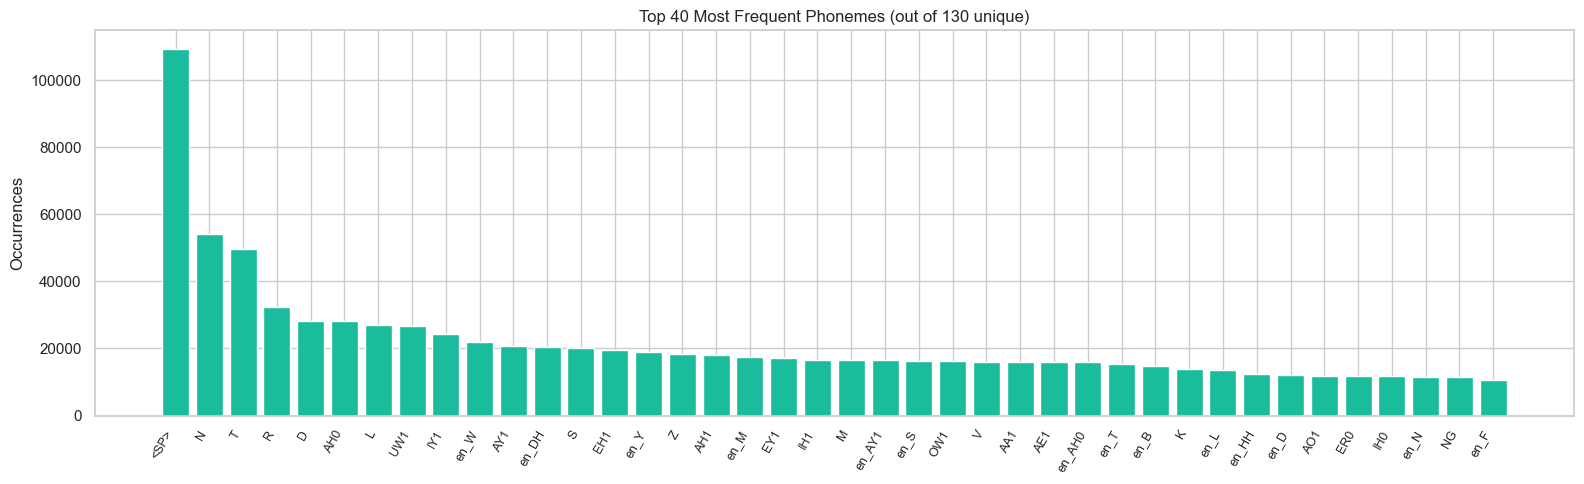

,Phoneme,Count,Pct
0,<SP>,109341,10.77
1,N,54129,5.33
2,T,49594,4.88
3,R,32257,3.18
4,D,28217,2.78
...,...,...,...
125,en_AW2,4,0.00
126,en_IY0,4,0.00
127,OY0,3,0.00
128,en_AY2,2,0.00


In [ ]:
# Phoneme frequency bar chart (top 40 + full table)
top_n = 40
most_common = phoneme_counter.most_common(top_n)
labels, counts = zip(*most_common)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(labels)), counts, color="#1abc9c", edgecolor="white")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("Occurrences")
ax.set_title(f"Top {top_n} Most Frequent Phonemes (out of {len(vocab)} unique)")
plt.tight_layout()
plt.show()

# Full frequency table
ph_df = pd.DataFrame(phoneme_counter.most_common(), columns=["Phoneme", "Count"])
ph_df["Pct"] = (100 * ph_df["Count"] / ph_df["Count"].sum()).round(2)
ph_df

In [ ]:
print(phoneme_counter.keys())

dict_keys(['en_W', 'IY1', 'R', 'en_D', 'AY1', 'V', 'IH0', 'NG', '<SP>', 'en_S', 'L', 'OW1', 'en_TH', 'UW1', 'en_DH', 'AH0', 'N', 'en_AA1', 'en_AE1', 'UW2', 'en_B', 'T', 'S', 'en_F', 'AE1', 'en_R', 'en_N', 'AW1', 'en_AY1', 'IH1', 'en_IH1', 'Z', 'en_P', 'AA1', 'EH1', 'en_EH1', 'D', 'en_K', 'en_T', 'EY1', 'K', 'IY0', 'en_L', 'AO1', 'G', 'ER0', 'en_AO1', 'P', 'en_AW1', 'F', 'en_G', 'UH2', 'B', 'en_AH0', 'en_Y', 'en_HH', 'en_JH', 'AH1', 'en_AH1', 'M', 'en_OW1', 'UW0', 'OW2', 'ER1', 'en_M', 'en_EY1', 'TH', 'EH2', 'en_IH0', 'W', 'UH1', 'IH2', 'AY2', 'en_IY1', 'en_IH2', 'Y', 'en_AH2', 'CH', 'EY2', 'AA2', 'IY2', 'en_SH', 'en_UW1', 'OW0', 'AO2', 'en_AE2', 'en_ER0', 'DH', 'en_CH', 'JH', 'SH', 'AW2', 'AH2', 'OY1', 'en_EH2', 'ER2', 'en_AO2', 'HH', 'AE2', 'AA0', 'en_EH0', 'AE0', 'en_V', 'en_AE0', 'en_ER1', 'ZH', 'en_OY1', 'EY0', 'UH0', 'en_OW2', 'en_UW0', 'en_UW2', 'AO0', 'AW0', 'en_AO0', 'OY0', 'EH0', 'en_Z', 'AY0', 'en_OW0', 'OY2', 'en_AW0', 'en_AW2', 'en_AA2', 'en_EY0', 'en_AA0', 'en_AY0', 'en_IY

## 5. Worst-Aligned Songs

Songs with the highest mean DTW cost — candidates for investigation or exclusion.

In [ ]:
# Worst-aligned songs by mean DTW cost
song_stats = manifest.groupby("dali_id").agg(
    mean_dtw=("dtw_cost", "mean"),
    max_dtw=("dtw_cost", "max"),
    convergence_rate=("converged", "mean"),
    n_chunks=("chunk_name", "count")
).sort_values("mean_dtw", ascending=False)

print("Top 10 worst-aligned songs (by mean DTW cost):")
song_stats.head(10)

Top 10 worst-aligned songs (by mean DTW cost):


,mean_dtw,max_dtw,convergence_rate,n_chunks
dali_id,,,,
200445ad95354a6b85599181aab57814,223.212211,411.0161,0.388889,18
0a471f786bda4c8ba2d2c9d7f34e5505,178.865871,220.5725,0.125000,24
20d0a6f4e991402598438d6721dc0040,161.384367,203.2933,0.333333,24
23b4f5722715425a893bdb06a8ea8341,152.586777,1388.3781,0.485714,35
1dabdcf3f6814e20b99078e003ff2b51,149.308229,326.8115,0.157895,38
311e535619494803b1a2093b9722d0d1,145.964326,296.4000,0.518519,27
14532086fea84b908fc7beac3d0ffd89,144.363645,314.5723,0.241379,29
22e37faa4f5241fb9113bb47d6c094d3,141.785468,239.3066,0.315789,19
1c1e636e4c1b4374acbba4a0504a6190,140.964250,233.1950,0.681818,22


## 6. Mel Spectrogram Length Comparison

Compare prior vs target mel-spectrogram lengths (frame counts) on a sample to assess how well durations match after alignment.

Loading mel shapes:   0%|          | 0/2000 [00:00<?, ?it/s]

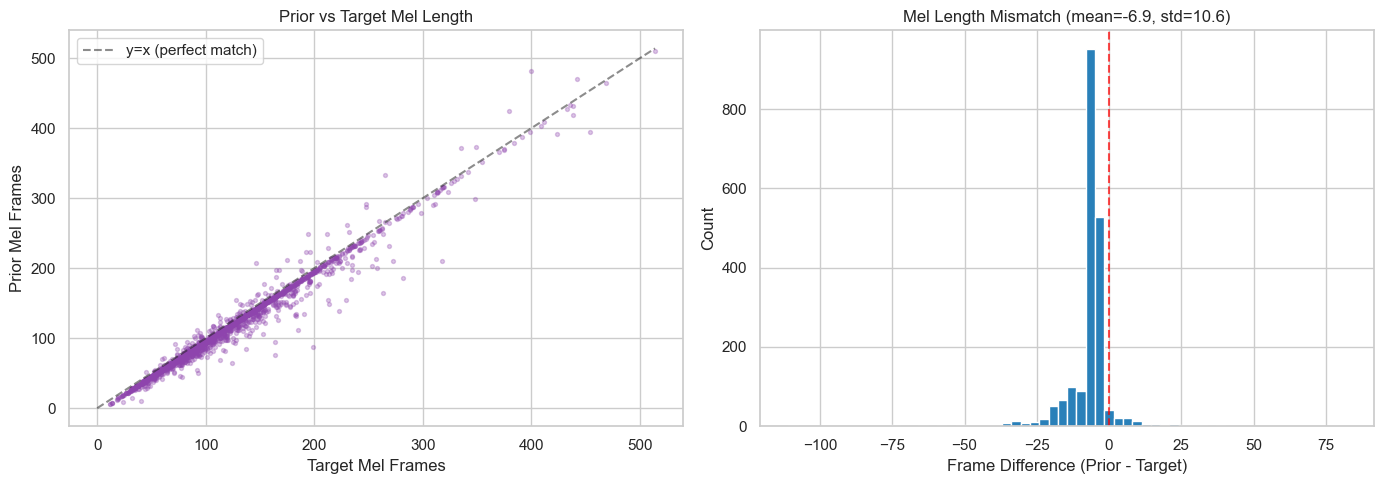

In [ ]:
# Sample mel lengths (reading all .npy is slow, sample 2000 chunks)
sample_size = min(2000, len(manifest))
sample = manifest.sample(sample_size, random_state=42)

prior_frames = []
target_frames = []

for _, row in tqdm(sample.iterrows(), total=sample_size, desc="Loading mel shapes"):
    try:
        p = np.load(DATA_DIR / row["prior_mel_path"])
        t = np.load(DATA_DIR / row["target_mel_path"])
        prior_frames.append(p.shape[0])
        target_frames.append(t.shape[0])
    except Exception:
        prior_frames.append(np.nan)
        target_frames.append(np.nan)

prior_frames = np.array(prior_frames, dtype=float)
target_frames = np.array(target_frames, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prior vs target frame count scatter
valid_mask = ~(np.isnan(prior_frames) | np.isnan(target_frames))
axes[0].scatter(target_frames[valid_mask], prior_frames[valid_mask], alpha=0.3, s=8, color="#8e44ad")
max_val = max(np.nanmax(prior_frames), np.nanmax(target_frames))
axes[0].plot([0, max_val], [0, max_val], "k--", alpha=0.5, label="y=x (perfect match)")
axes[0].set_xlabel("Target Mel Frames")
axes[0].set_ylabel("Prior Mel Frames")
axes[0].set_title("Prior vs Target Mel Length")
axes[0].legend()

# Frame difference histogram
frame_diff = prior_frames[valid_mask] - target_frames[valid_mask]
axes[1].hist(frame_diff, bins=60, color="#2980b9", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", alpha=0.7)
axes[1].set_xlabel("Frame Difference (Prior - Target)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Mel Length Mismatch (mean={np.mean(frame_diff):.1f}, std={np.std(frame_diff):.1f})")

plt.tight_layout()
plt.show()

## 7. Summary Statistics

In [ ]:
# Summary table
summary = {
    "Total English DALI songs": total_english,
    "Songs processed": processed_count,
    "Coverage (%)": f"{100*processed_count/total_english:.1f}",
    "Total chunks": len(manifest),
    "Converged chunks": int(manifest["converged"].sum()),
    "Convergence rate (%)": f"{100*manifest['converged'].mean():.1f}",
    "Median DTW cost": f"{manifest['dtw_cost'].median():.2f}",
    "Median chunk duration (s)": f"{manifest['duration_s'].median():.2f}",
    "Median words per chunk": f"{manifest['word_count'].median():.0f}",
    "Total notes": f"{len(all_pitches):,}",
    "Total dataset duration (hrs)": f"{manifest['duration_s'].sum() / 3600:.1f}",
}

pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])

,Value
Total English DALI songs,5913
Songs processed,1175
Coverage (%),19.9
Total chunks,64938
Converged chunks,16853
Convergence rate (%),26.0
Median DTW cost,56.36
Median chunk duration (s),2.16
Median words per chunk,5
Total notes,"408,417"
